# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

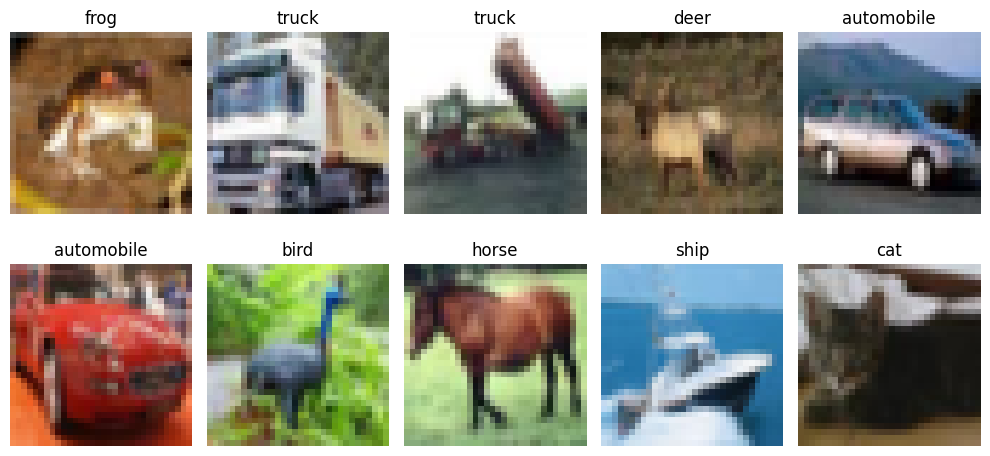

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - accuracy: 0.2510 - loss: 2.0224 - val_accuracy: 0.3322 - val_loss: 1.8546
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3072 - loss: 1.8817 - val_accuracy: 0.3440 - val_loss: 1.8360
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3307 - loss: 1.8301 - val_accuracy: 0.3758 - val_loss: 1.7666
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3436 - loss: 1.7893 - val_accuracy: 0.3754 - val_loss: 1.7415
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3555 - loss: 1.7680 - val_accuracy: 0.3782 - val_loss: 1.7395
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.3640 - loss: 1.7380 - val_accuracy: 0.4024 - val_loss: 1.6834
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.3721 - loss: 1.7293 - val_accuracy: 0.4060 - val_loss: 1.6826
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.3752 - loss: 1.7104 - 

In [9]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4308 - loss: 1.6150
ANN Test Accuracy: 0.4307999908924103


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [10]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 135ms/step - accuracy: 0.4539 - loss: 1.5405 - val_accuracy: 0.5002 - val_loss: 1.3974
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 127ms/step - accuracy: 0.5899 - loss: 1.1596 - val_accuracy: 0.4950 - val_loss: 1.3470
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.6483 - loss: 1.0011 - val_accuracy: 0.6442 - val_loss: 1.0633
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 127ms/step - accuracy: 0.6911 - loss: 0.8836 - val_accuracy: 0.6760 - val_loss: 0.9198
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.7195 - loss: 0.8039 - val_accuracy: 0.6462 - val_loss: 1.0554
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.7452 - loss: 0.7297 - val_accuracy: 0.6516 - val_loss: 1.0192
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.7648 - loss: 0.6699 - val_accuracy: 0.6858 - val_loss: 0.9038
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - accuracy: 0.7846 - los

In [17]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6867 - loss: 0.9263
CNN Test Accuracy: 0.6866999864578247


## 📈 Compare Learning Curves

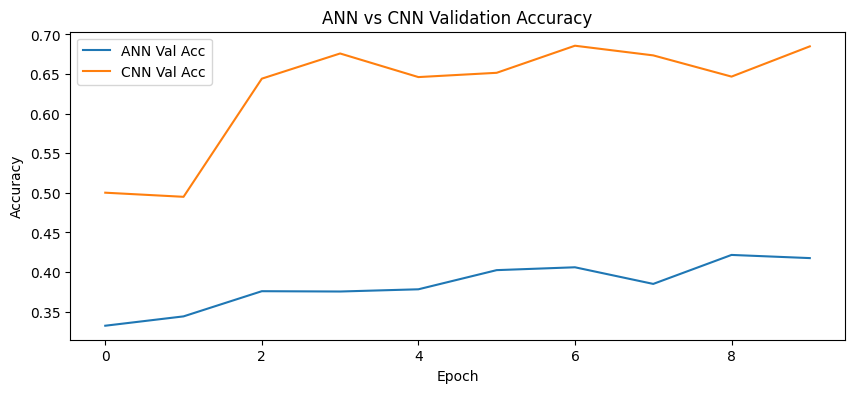

In [18]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 96ms/step - accuracy: 0.3665 - loss: 1.7379 - val_accuracy: 0.4928 - val_loss: 1.4177
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.4687 - loss: 1.4808 - val_accuracy: 0.5372 - val_loss: 1.2812
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5106 - loss: 1.3795 - val_accuracy: 0.5958 - val_loss: 1.1354
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 96ms/step - accuracy: 0.5314 - loss: 1.3215 - val_accuracy: 0.5842 - val_loss: 1.1497
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5450 - loss: 1.2829 - val_accuracy: 0.5912 - val_loss: 1.1569
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.5591 - loss: 1.2497 - val_accuracy: 0.6216 - val_loss: 1.0489
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5714 - loss: 1.2170 - val_accuracy: 0.6114 - val_loss: 1.0961
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.5802 - loss: 1.1904 - 

In [20]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6402 - loss: 1.0250
Augmented CNN Test Accuracy: 0.6402000188827515


# 📊 Final Comparison Table

In [21]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4308
1,CNN,0.6867
2,CNN + Augmentation,0.6402


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- The **augmented CNN** generalizes better on unseen data since it trains on randomly flipped, rotated, and zoomed versions of images
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**